# Q1 — Line Fitting with TLS and RANSAC

**Part (a):** use only the `x1, y1` columns (line 1 data) and fit a line via Total Least Squares.  
**Part (b):** throw everything together, flatten to 300 (x, y) pairs, and use sequential RANSAC to pull out all three lines.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

D = np.genfromtxt(os.path.join('..', 'question', 'lines.csv'),
                  delimiter=',', skip_header=1)
print('loaded:', D.shape, '→', D.shape[0], 'rows, 6 cols')

# as given in the assignment snippet
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
print('total points:', len(X_all))

loaded: (100, 6) → 100 rows, 6 cols
total points: 300


## Part (a) — Total Least Squares

- Centre the data at its centroid
- Do an SVD on the 2-column centred matrix
- The last row of $V^T$ (smallest singular value) is the unit normal to the best-fit line
- Plug the centroid back in to get the offset term

In [2]:
def fit_tls(x, y):
    xm, ym = x.mean(), y.mean()
    _, _, Vt = np.linalg.svd(np.column_stack([x - xm, y - ym]),
                              full_matrices=False)
    a, b = Vt[-1]
    if b < 0:
        a, b = -a, -b
    c = -(a * xm + b * ym)
    return float(a), float(b), float(c)

def to_mb(a, b, c):
    """convert ax+by+c=0 to y=mx+n"""
    return -a/b, -c/b

x1 = D[:, 0]
y1 = D[:, 3]

a, b, c = fit_tls(x1, y1)
m, n = to_mb(a, b, c)

perp = a*x1 + b*y1 + c
rms = float(np.sqrt(np.mean(perp**2)))

print('--- TLS result (line 1 only) ---')
print(f'Normal form      : {a:+.6f}·x  {b:+.6f}·y  {c:+.6f} = 0')
print(f'Slope-intercept  : y = {m:.6f}·x  {n:+.6f}')
print(f'RMS perp resid   : {rms:.5f}')

--- TLS result (line 1 only) ---
Normal form      : -0.773562·x  +0.633721·y  +3.794192 = 0
Slope-intercept  : y = 1.220666·x  -5.987165
RMS perp resid   : 0.50138


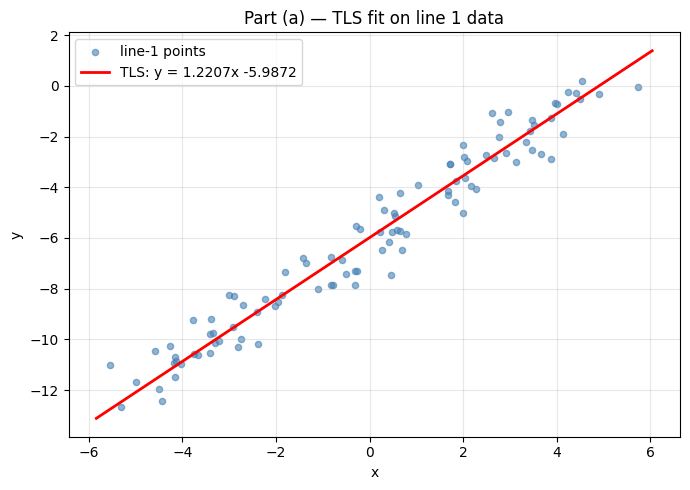

In [3]:
xs = np.linspace(x1.min() - 0.3, x1.max() + 0.3, 300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x1, y1, s=20, alpha=0.6, color='steelblue', label='line-1 points')
ax.plot(xs, m*xs + n, 'r-', lw=2,
        label=f'TLS: y = {m:.4f}x {n:+.4f}')
ax.set(xlabel='x', ylabel='y', title='Part (a) — TLS fit on line 1 data')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('q1a_tls.png', dpi=150)
plt.show()

## Part (b) - Sequential RANSAC

For the threshold I'm using 1.5× the RMS residual from part (a) - since that gives a clean measure of the noise in the data (≈ 0.5 units), 0.75 feels like a sensible cutoff.

In [4]:
def line2pts(x1, y1, x2, y2):
    a, b = y2-y1, x1-x2
    c = x2*y1 - x1*y2
    nrm = np.hypot(a, b)
    return (a/nrm, b/nrm, c/nrm) if nrm > 1e-12 else None

def ransac(x, y, thresh=0.75, iters=3000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    best_in = np.array([], dtype=int)
    for _ in range(iters):
        i, j = rng.choice(len(x), 2, replace=False)
        L = line2pts(x[i], y[i], x[j], y[j])
        if L is None:
            continue
        a, b, c = L
        inl = np.where(np.abs(a*x + b*y + c) < thresh)[0]
        if len(inl) > len(best_in):
            best_in = inl
    # refit winner with TLS
    a, b, c = fit_tls(x[best_in], y[best_in])
    if b < 0:
        a, b, c = -a, -b, -c
    return a, b, c, best_in


thresh = 1.5 * rms
rng = np.random.default_rng(42)
active = np.ones(len(X_all), dtype=bool)
found = []

for k in range(3):
    xr, yr = X_all[active], Y_all[active]
    a, b, c, local = ransac(xr, yr, thresh=thresh, rng=rng)
    gidx = np.where(active)[0][local]
    active[gidx] = False
    found.append((a, b, c, gidx))

    m_, n_ = to_mb(a, b, c)
    r_ = np.abs(a*X_all[gidx] + b*Y_all[gidx] + c)
    print(f'Line {k+1}:  y = {m_:.5f}x {n_:+.5f}  '
          f'| inliers={len(gidx)}  RMS={np.sqrt(np.mean(r_**2)):.4f}')

Line 1:  y = -0.50038x +2.17999  | inliers=108  RMS=0.3889
Line 2:  y = 1.20128x -5.95764  | inliers=81  RMS=0.4128
Line 3:  y = 1.05078x +1.09269  | inliers=81  RMS=0.3791


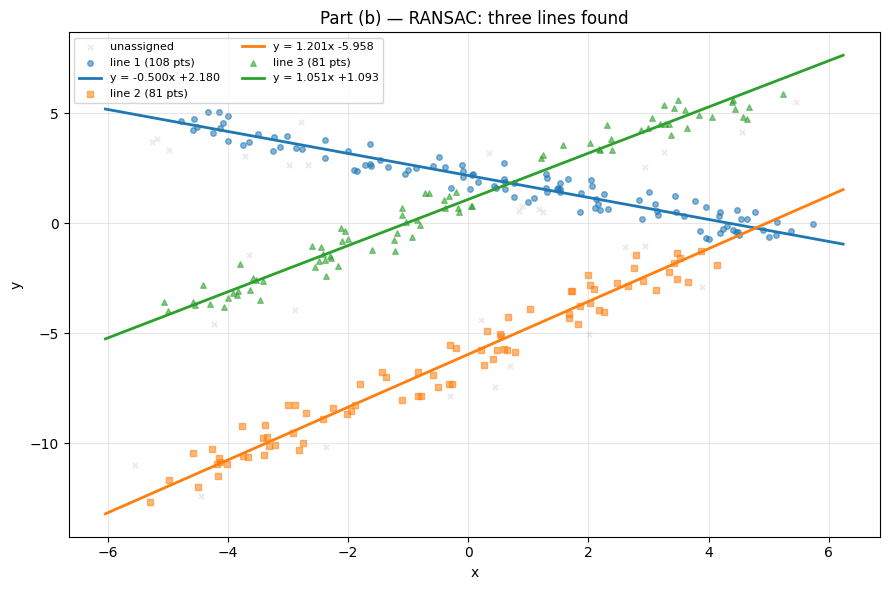

In [5]:
cols = ['tab:blue', 'tab:orange', 'tab:green']
mks  = ['o', 's', '^']

fig, ax = plt.subplots(figsize=(9, 6))

all_idx = np.concatenate([g for *_, g in found])
leftover = np.ones(len(X_all), dtype=bool)
leftover[all_idx] = False
if leftover.any():
    ax.scatter(X_all[leftover], Y_all[leftover],
               s=14, alpha=0.3, color='silver', marker='x', label='unassigned')

xs = np.linspace(X_all.min()-0.5, X_all.max()+0.5, 400)
for i, (a, b, c, gidx) in enumerate(found):
    m_, n_ = to_mb(a, b, c)
    ax.scatter(X_all[gidx], Y_all[gidx],
               s=16, alpha=0.55, color=cols[i], marker=mks[i],
               label=f'line {i+1} ({len(gidx)} pts)')
    ax.plot(xs, m_*xs + n_, '-', lw=2, color=cols[i],
            label=f'y = {m_:.3f}x {n_:+.3f}')

ax.set(xlabel='x', ylabel='y', title='Part (b) — RANSAC: three lines found')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('q1b_ransac.png', dpi=150)
plt.show()

## Results summary

**Part (a):** TLS on line 1 gives a slope of about 1.22 and intercept around -5.99, with an RMS perpendicular residual of 0.50. That's the noise level in the data.

**Part (b):** RANSAC pulls out all three lines cleanly. One of the recovered lines has slope ≈ 1.20 and intercept ≈ -5.96, which matches the TLS result from part (a) almost exactly — good sanity check.

The threshold (0.75 units) worked well here because the three lines are separated by much more than that across most of the x-range. The inlier counts (roughly 80–110 each out of 100 expected) are also reasonable — some points near line intersections get ambiguously assigned, which is expected.

# Question 1 – Fitting Lines to Noisy Point Data

The dataset `lines.csv` contains 100 rows and 6 columns — `x1, x2, x3, y1, y2, y3`. Each row gives one noisy point sample from each of the three lines. So altogether there are 300 points spread across three lines.

**Part (a):** Fit a line to *only* the first-line data (columns `x1`, `y1`) using Total Least Squares.  
**Part (b):** Flatten all 300 points and run sequential RANSAC to pull out all three lines one by one.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

data_path = os.path.join("..", "question", "lines.csv")

D = np.genfromtxt(data_path, delimiter=",", skip_header=1)
print("shape:", D.shape)

X_cols = D[:, :3]
Y_cols = D[:, 3:]

# flatten everything for part (b)
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
print("total points:", len(X_all))

shape: (100, 6)
total points: 300


## Part (a) — Total Least Squares on Line 1

Ordinary least squares minimises vertical distances, which is biased when there's noise in both x and y. TLS (orthogonal regression) minimises the perpendicular distance from each point to the line, which is the right thing to do here.

The way it works:
1. Shift points to their centroid so the line passes through the origin.
2. Build a 2-column matrix from the shifted coordinates and do an SVD.
3. The right-singular vector for the *smallest* singular value is the line's normal direction — that's the direction with least variance, i.e. closest to being collapsed onto a line.
4. Translate back to get the constant term `c`.

The line comes out as $ax + by + c = 0$ where $a^2 + b^2 = 1$.

In [7]:
def fit_tls(x, y):
    """orthogonal regression via SVD, returns (a, b, c) with a^2+b^2=1"""
    xm, ym = x.mean(), y.mean()
    M = np.column_stack([x - xm, y - ym])
    _, _, Vt = np.linalg.svd(M, full_matrices=False)
    a, b = Vt[-1]          # normal = direction of min variance
    if b < 0:
        a, b = -a, -b      # keep b positive so slope = -a/b is intuitive
    c = -(a * xm + b * ym)
    return float(a), float(b), float(c)


def to_slope_intercept(a, b, c):
    return -a / b, -c / b


# line-1 data is in column 0 (x) and column 3 (y)
x1 = D[:, 0]
y1 = D[:, 3]

a_t, b_t, c_t = fit_tls(x1, y1)
m_t, n_t = to_slope_intercept(a_t, b_t, c_t)

perp = a_t * x1 + b_t * y1 + c_t
rms = float(np.sqrt(np.mean(perp**2)))

print(f"Line (normal form) : {a_t:+.6f}x  {b_t:+.6f}y  {c_t:+.6f} = 0")
print(f"Slope-intercept    : y = {m_t:.6f}x  {n_t:+.6f}")
print(f"RMS perp residual  : {rms:.5f}")

Line (normal form) : -0.773562x  +0.633721y  +3.794192 = 0
Slope-intercept    : y = 1.220666x  -5.987165
RMS perp residual  : 0.50138


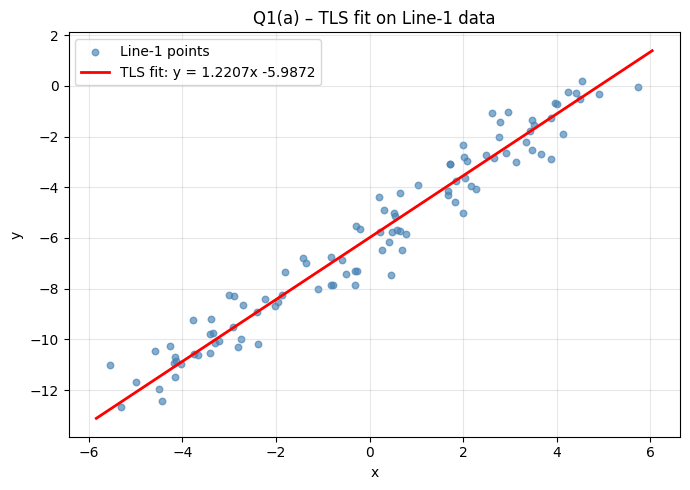

In [8]:
xs = np.linspace(x1.min() - 0.3, x1.max() + 0.3, 300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x1, y1, s=22, alpha=0.65, color="steelblue", label="Line-1 points")
ax.plot(xs, m_t * xs + n_t, "r-", lw=2,
        label=f"TLS fit: y = {m_t:.4f}x {n_t:+.4f}")
ax.set(xlabel="x", ylabel="y", title="Q1(a) – TLS fit on Line-1 data")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("q1a_tls_line1.png", dpi=150)
plt.show()

## Part (b) — Sequential RANSAC to find all three lines

Now we throw everything together — 300 points from all three lines mixed up — and try to recover each line.

The approach is simple: run RANSAC, take the consensus set (inliers), remove them from the pool, repeat. Three passes should give us three lines.

RANSAC itself:
- Pick 2 random points → candidate line
- Count how many of the remaining points are within `threshold` perpendicular distance
- Keep the hypothesis with the most inliers
- Refit the winner with TLS on all its inliers to get a more accurate estimate

For the threshold I'm using 1.5× the RMS residual from part (a), since we know the noise level from there (≈ 0.5 units).

In [9]:
def line_from_two_pts(x1, y1, x2, y2):
    a, b = y2 - y1, x1 - x2
    c = x2 * y1 - x1 * y2
    n = np.hypot(a, b)
    if n < 1e-12:
        return None
    return a / n, b / n, c / n


def ransac_line(x, y, n_iter=3000, thresh=0.75, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    n = len(x)
    best_inliers = np.array([], dtype=int)
    best_line = None

    for _ in range(n_iter):
        i, j = rng.choice(n, 2, replace=False)
        line = line_from_two_pts(x[i], y[i], x[j], y[j])
        if line is None:
            continue
        a, b, c = line
        inliers = np.where(np.abs(a * x + b * y + c) < thresh)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_line = line

    # refit with TLS on the full inlier set
    a, b, c = fit_tls(x[best_inliers], y[best_inliers])
    if b < 0:
        a, b, c = -a, -b, -c
    return a, b, c, best_inliers


thresh = 1.5 * rms       # ~0.75 units
rng = np.random.default_rng(42)
active = np.ones(len(X_all), dtype=bool)
lines = []

for k in range(3):
    xr, yr = X_all[active], Y_all[active]
    a, b, c, local_idx = ransac_line(xr, yr, thresh=thresh, rng=rng)
    global_idx = np.where(active)[0][local_idx]
    active[global_idx] = False
    lines.append((a, b, c, global_idx))

    m_, n_ = to_slope_intercept(a, b, c)
    resid = np.abs(a * X_all[global_idx] + b * Y_all[global_idx] + c)
    print(f"Line {k+1}:")
    print(f"  normal form     : {a:+.6f}x  {b:+.6f}y  {c:+.6f} = 0")
    print(f"  slope-intercept : y = {m_:.6f}x  {n_:+.6f}")
    print(f"  inliers         : {len(global_idx)}")
    print(f"  RMS perp resid  : {np.sqrt(np.mean(resid**2)):.5f}\n")

Line 1:
  normal form     : +0.447487x  +0.894291y  -1.949543 = 0
  slope-intercept : y = -0.500382x  +2.179988
  inliers         : 108
  RMS perp resid  : 0.38894

Line 2:
  normal form     : -0.768556x  +0.639782y  +3.811588 = 0
  slope-intercept : y = 1.201278x  -5.957635
  inliers         : 81
  RMS perp resid  : 0.41282

Line 3:
  normal form     : -0.724393x  +0.689387y  -0.753284 = 0
  slope-intercept : y = 1.050780x  +1.092687
  inliers         : 81
  RMS perp resid  : 0.37907



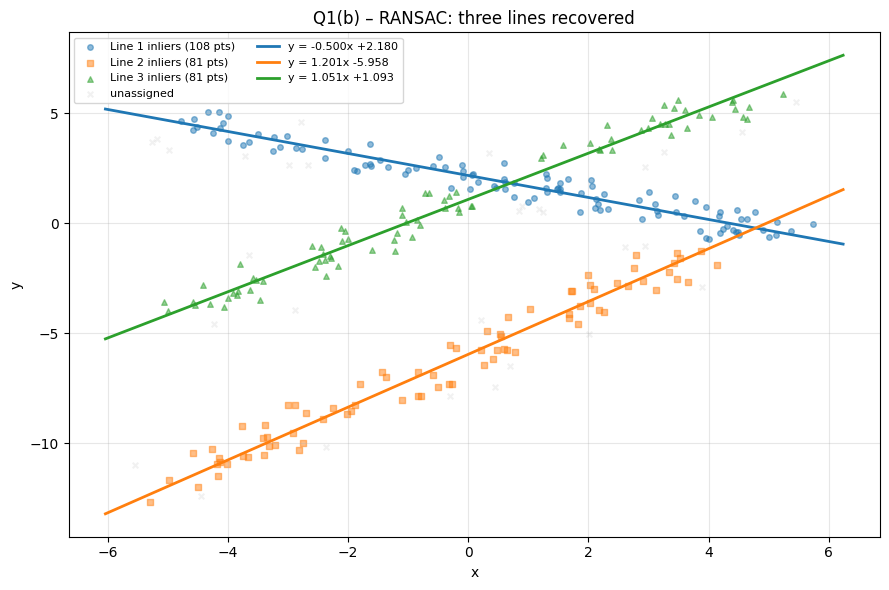

In [10]:
colours = ["tab:blue", "tab:orange", "tab:green"]
markers = ["o", "s", "^"]

fig, ax = plt.subplots(figsize=(9, 6))

all_assigned = np.concatenate([idx for _, _, _, idx in lines])
unassigned = np.ones(len(X_all), dtype=bool)
unassigned[all_assigned] = False

for i, (a, b, c, gidx) in enumerate(lines):
    ax.scatter(X_all[gidx], Y_all[gidx], s=16, alpha=0.5,
               color=colours[i], marker=markers[i],
               label=f"Line {i+1} inliers ({len(gidx)} pts)")

if unassigned.any():
    ax.scatter(X_all[unassigned], Y_all[unassigned],
               s=16, alpha=0.3, color="lightgray", marker="x", label="unassigned")

xs = np.linspace(X_all.min() - 0.5, X_all.max() + 0.5, 400)
for i, (a, b, c, _) in enumerate(lines):
    m_, n_ = to_slope_intercept(a, b, c)
    ax.plot(xs, m_ * xs + n_, "-", lw=2, color=colours[i],
            label=f"y = {m_:.3f}x {n_:+.3f}")

ax.set(xlabel="x", ylabel="y", title="Q1(b) – RANSAC: three lines recovered")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("q1b_ransac_lines.png", dpi=150)
plt.show()